# Tutorial 1: Player strategies, masking strategies, and failure modes

This notebook walks through `shapiq.vision` by explaining the *same* image with a matrix of

- **model architectures**: `ResNetArchitecture`, `ViTArchitecture`, `ConvNeXtArchitecture`, `DINOv2Architecture`, `CLIPArchitecture`
- **player strategies**: `SuperpixelStrategy` (SLIC), `PatchStrategy` (fixed grid)
- **masking strategies**: `MeanColorMasking`, `ZeroMasking` (pixel-space), `BoolMaskedPosStrategy`, `MaskTokenStrategy` (ViT attention)

It then shows **where the method breaks down**: adversarial examples, out-of-distribution inputs, and low-confidence predictions. These failure modes are an essential part of any honest evaluation of an explainability method.

In [42]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import models, transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


### Load a single image used everywhere below


image shape: (224, 224, 3)


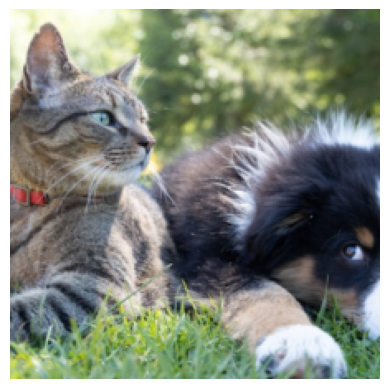

In [43]:
URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
resize = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
pil_image = resize(raw)
image = np.array(pil_image)
print("image shape:", image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

A dog and a cat laying in the grass together.
Both animals are visible in the 224x224 crop, so the dog region gets negative Shapley
values for the 'tabby' class (removing it *helps* the cat score) while the cat region
gets positive values. This creates the red/green contrast that reveals how each
architecture handles a competing, same-domain distractor.

### A helper for visualizing first-order Shapley values as a heatmap over the image

In [44]:
import matplotlib.colors as mcolors
from matplotlib import cm


def heatmap_from_pixel_masks(values, masks, image_shape):
    """Project per-player Shapley values back onto pixel space using player masks."""
    heat = np.zeros(image_shape[:2])
    for i, v in enumerate(values):
        heat[masks[i]] = v
    return heat


def plot_overlay(image, heat, title, ax):
    ax.imshow(image)
    vmax = max(abs(heat.min()), abs(heat.max())) + 1e-9
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    ax.imshow(heat, cmap=cm.RdYlGn, norm=norm, alpha=0.55)
    ax.set_title(title)
    ax.axis("off")

## 1. ResNet-18 × SuperpixelStrategy × {MeanColorMasking, ZeroMasking}

Two pixel-space maskers on the same superpixel partition. Switching the masker keeps the players fixed but changes what "absent" means.


ResNet predicted class: 281 tabby


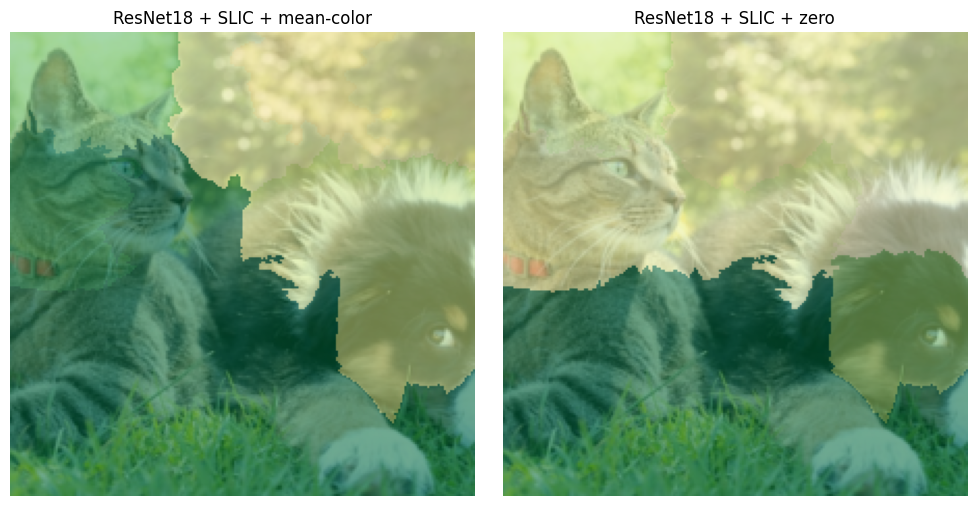

In [45]:
from shapiq import ImageExplainer
from shapiq.vision import ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking, ZeroMasking

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).eval().to(device)
weights = models.ResNet18_Weights.DEFAULT
preprocess = transforms.Compose([transforms.ToTensor(), weights.transforms()])

with torch.no_grad():
    class_id = int(resnet(preprocess(pil_image).unsqueeze(0).to(device)).argmax(-1).item())
print("ResNet predicted class:", class_id, weights.meta["categories"][class_id])


def resnet_model(batch_hwc: np.ndarray) -> np.ndarray:
    pil_batch = [Image.fromarray(arr.astype(np.uint8)) for arr in batch_hwc]
    tensors = torch.stack([preprocess(im) for im in pil_batch]).to(device)
    with torch.no_grad():
        logits = resnet(tensors)
    return logits[:, class_id].cpu().numpy()


results_resnet = {}
for masker_name, masker in [("mean-color", MeanColorMasking()), ("zero", ZeroMasking())]:
    arch = ResNetArchitecture(model=resnet_model, masking_strategy=masker)
    explainer = ImageExplainer(
        architecture=arch,
        data=image,
        player_strategy=SuperpixelStrategy(n_segments=10),
        batch_size=16,
        random_state=0,
    )
    iv = explainer.explain_function(image, budget=128)
    results_resnet[masker_name] = (iv, explainer.imputer.player_masks)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, (iv, masks)) in zip(axes, results_resnet.items(), strict=False):
    first_order = iv.get_n_order_values(1)
    heat = heatmap_from_pixel_masks(first_order, masks, image.shape)
    plot_overlay(image, heat, f"ResNet18 + SLIC + {name}", ax)
plt.tight_layout()
plt.show()

## 2. ViT-B/16 × PatchStrategy × {BoolMaskedPos, MaskToken}

Two latent-space maskers on a 3×3 patch grid. Both use the same patch player strategy but differ in *how* they mask the token embeddings before the forward pass.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

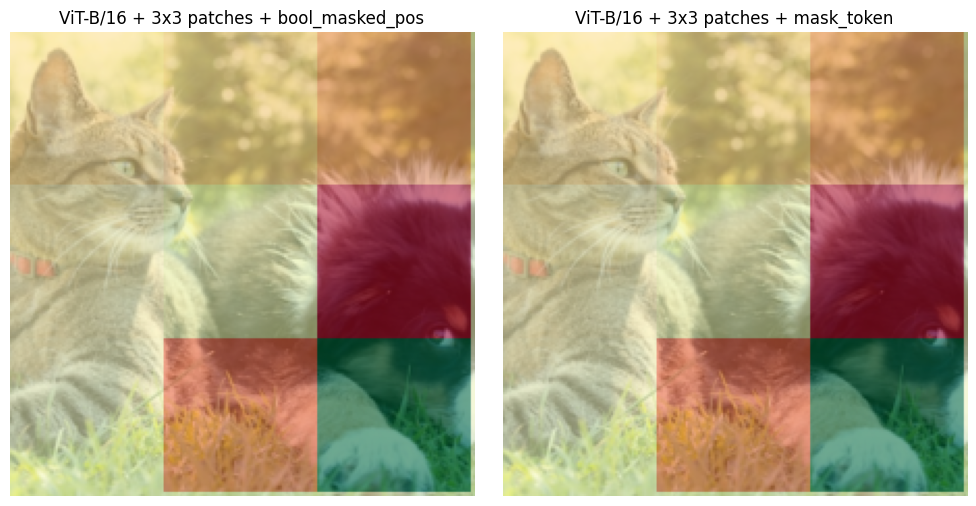

In [46]:
from transformers import ViTForImageClassification, ViTImageProcessor

from shapiq.vision import PatchStrategy, ViTArchitecture
from shapiq.vision.masking import BoolMaskedPosStrategy, MaskTokenStrategy

vit_id = "google/vit-base-patch16-224"
vit_processor = ViTImageProcessor.from_pretrained(vit_id)
vit_model = ViTForImageClassification.from_pretrained(vit_id).eval()
grid_size = vit_model.config.image_size // vit_model.config.patch_size
patch_strategy = PatchStrategy(grid_size=grid_size, n_players=9)  # 3×3 player grid

results_vit = {}
for name, masker in [
    ("bool_masked_pos", BoolMaskedPosStrategy()),
    ("mask_token", MaskTokenStrategy()),
]:
    arch = ViTArchitecture(model=vit_model, processor=vit_processor, masking_strategy=masker)
    explainer = ImageExplainer(
        architecture=arch,
        data=image,
        player_strategy=patch_strategy,
        batch_size=8,
        random_state=0,
    )
    iv = explainer.explain_function(image, budget=128)
    results_vit[name] = iv


# Render each 3x3 latent attribution back onto the image via the patch grid.
def latent_heatmap(iv, side, image_shape):
    first = iv.get_n_order_values(1)
    H, W = image_shape[:2]
    block_h, block_w = H // side, W // side
    heat = np.zeros((H, W))
    for i, v in enumerate(first):
        y, x = (i // side) * block_h, (i % side) * block_w
        heat[y : y + block_h, x : x + block_w] = v
    return heat


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, iv) in zip(axes, results_vit.items(), strict=False):
    heat = latent_heatmap(iv, side=3, image_shape=image.shape)
    plot_overlay(image, heat, f"ViT-B/16 + 3x3 patches + {name}", ax)
plt.tight_layout()
plt.show()

## 3. ConvNeXt-tiny × SuperpixelStrategy × MeanColorMasking

`ConvNeXtArchitecture` is a thin subclass of `HuggingFacePixelArchitecture`: pixel-space masking + HF processor.


Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

ConvNeXt predicted class: 282


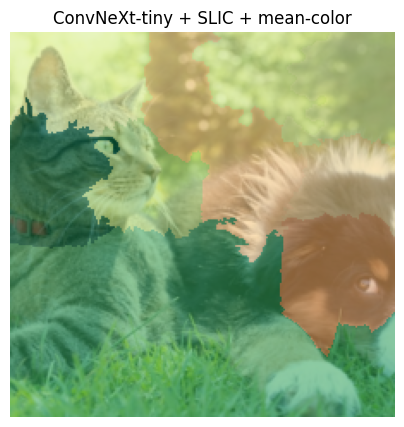

In [47]:
from transformers import AutoImageProcessor, ConvNextForImageClassification

from shapiq.vision import ConvNeXtArchitecture

convnext_id = "facebook/convnext-tiny-224"
convnext_processor = AutoImageProcessor.from_pretrained(convnext_id)
convnext_model = ConvNextForImageClassification.from_pretrained(convnext_id).eval()

convnext_arch = ConvNeXtArchitecture(model=convnext_model, processor=convnext_processor)
explainer = ImageExplainer(
    architecture=convnext_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
iv_convnext = explainer.explain_function(image, budget=128)
print("ConvNeXt predicted class:", convnext_arch.class_id)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_convnext.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, "ConvNeXt-tiny + SLIC + mean-color", ax)
plt.show()

## 4. DINOv2 × SuperpixelStrategy × MeanColorMasking (feature similarity)

DINOv2 has no classification head, so the value function returns the **cosine similarity** between the masked-image embedding and the original-image embedding. Higher = closer to the original.


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

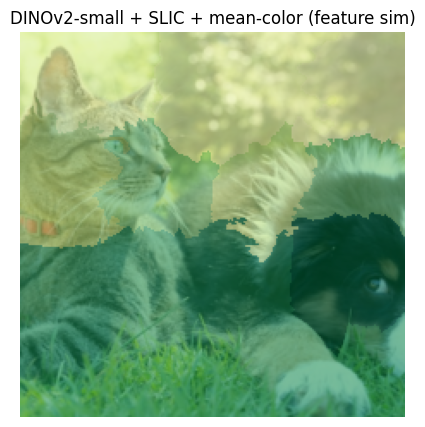

In [48]:
from transformers import AutoImageProcessor, AutoModel

from shapiq.vision import DINOv2Architecture

dino_id = "facebook/dinov2-small"
dino_processor = AutoImageProcessor.from_pretrained(dino_id)
dino_model = AutoModel.from_pretrained(dino_id).eval()

dino_arch = DINOv2Architecture(model=dino_model, processor=dino_processor)
explainer = ImageExplainer(
    architecture=dino_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
iv_dino = explainer.explain_function(image, budget=128)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_dino.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, "DINOv2-small + SLIC + mean-color (feature sim)", ax)
plt.show()

## 5. CLIP × SuperpixelStrategy × MeanColorMasking (zero-shot text prompts)

CLIP scores the masked image against a list of text prompts. The value function returns the softmax probability over the prompt set for the target prompt.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


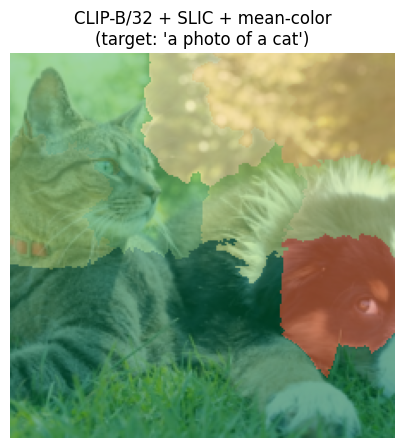

In [49]:
from transformers import CLIPModel, CLIPProcessor

from shapiq.vision import CLIPArchitecture

clip_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_id)
clip_model = CLIPModel.from_pretrained(clip_id).eval()

PROMPTS = ["a photo of a cat", "a photo of a dog", "a photo of a car", "a photo of a tree"]
clip_arch = CLIPArchitecture(
    model=clip_model, processor=clip_processor, text_prompts=PROMPTS, target_prompt_idx=0
)
explainer = ImageExplainer(
    architecture=clip_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=8,
    random_state=0,
)
iv_clip = explainer.explain_function(image, budget=128)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_clip.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, f"CLIP-B/32 + SLIC + mean-color\n(target: '{PROMPTS[0]}')", ax)
plt.show()

## 6. Side-by-side: same image, all architectures

The per-player first-order Shapley values from each architecture are placed on one figure. Because the image and partition are identical, this is a direct comparison of where each model locates the relevant evidence.


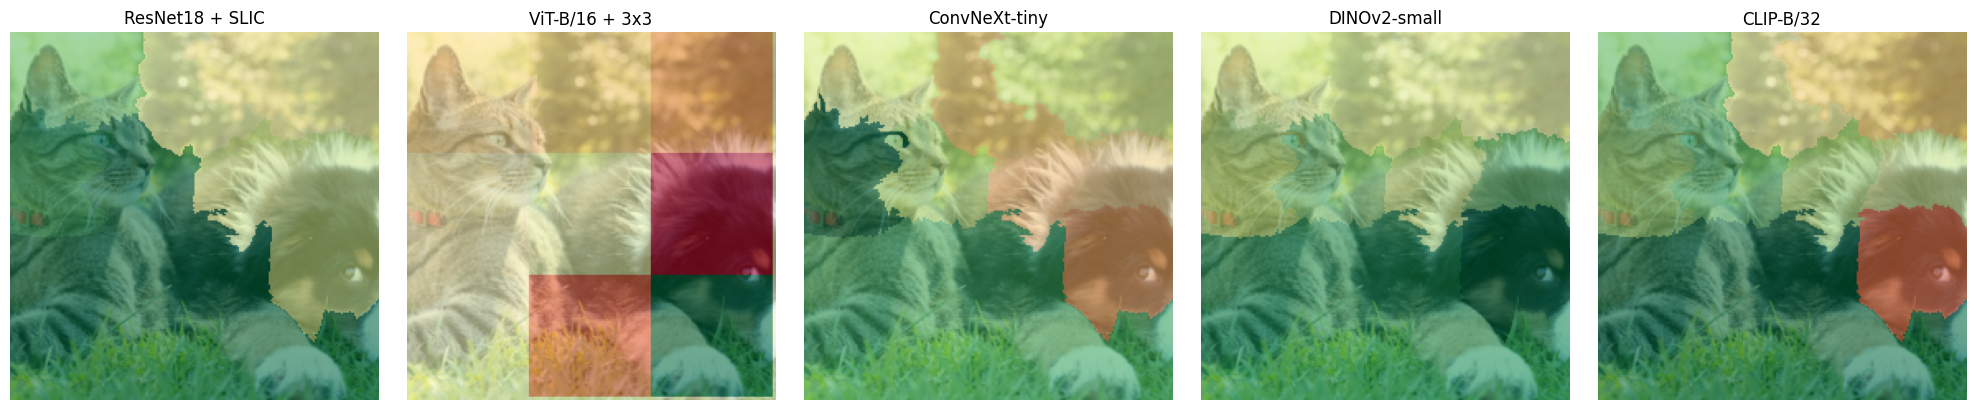

In [50]:
panels = [
    ("ResNet18 + SLIC", results_resnet["mean-color"][0], results_resnet["mean-color"][1], "pixel"),
    ("ViT-B/16 + 3x3", results_vit["bool_masked_pos"], None, "latent"),
    ("ConvNeXt-tiny", iv_convnext, explainer.imputer.player_masks, "pixel"),
    ("DINOv2-small", iv_dino, explainer.imputer.player_masks, "pixel"),
    ("CLIP-B/32", iv_clip, explainer.imputer.player_masks, "pixel"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for ax, (title, iv, masks, kind) in zip(axes, panels, strict=False):
    first = iv.get_n_order_values(1)
    heat = (
        latent_heatmap(iv, side=3, image_shape=image.shape)
        if kind == "latent"
        else heatmap_from_pixel_masks(first, masks, image.shape)
    )
    plot_overlay(image, heat, title, ax)
plt.tight_layout()
plt.show()

---

## 7. Failure modes and edge cases

Honest evaluation of a method requires showing where it breaks down. In this section we stress-test the imputer with three types of challenging inputs:

1. **Adversarial noise** — a small structured perturbation that flips the ResNet prediction with minimal perceptual change. The explanation should behave differently on the attacked image.
2. **Out-of-distribution (OOD) input** — pure Gaussian noise. No model was trained on this; the explanation will be unreliable.
3. **Low-confidence / ambiguous prediction** — an image that genuinely sits between two classes. The explanation should show diffuse, small attributions rather than a clear focus region.

These examples illustrate important caveats: Shapley values faithfully decompose *whatever the model outputs* — but if the model itself is confused or fooled, the explanation inherits that confusion.


### 7.1  Adversarial example (Fast Gradient Sign Method)

In [ ]:
import copy

import torch
import torch.nn.functional as F
from torchvision import models, transforms

# ── Build ResNet-18 differentiable pipeline ─────────────────────────────────
rn18_weights = models.ResNet18_Weights.DEFAULT
rn18 = models.resnet18(weights=rn18_weights).eval()

# Transforms: to tensor + ImageNet normalise
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

x = to_tensor(pil_image).unsqueeze(0)  # (1, 3, 224, 224)
x.requires_grad_(True)

# Forward pass to get target class
with torch.no_grad():
    logits = rn18(x.detach())
    target_class_rn = int(logits.argmax(-1).item())
print(f"Original prediction: {target_class_rn} — {rn18_weights.meta['categories'][target_class_rn]}")

# FGSM: epsilon perturbation in direction of gradient
loss = F.cross_entropy(rn18(x), torch.tensor([target_class_rn]))
loss.backward()

epsilon = 0.02  # small enough to be nearly invisible
x_adv = (x + epsilon * x.grad.sign()).clamp(-3, 3)

with torch.no_grad():
    adv_logits = rn18(x_adv)
    adv_class = int(adv_logits.argmax(-1).item())

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
adv_image_np = ((x_adv.squeeze(0).detach() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype("uint8")

print(f"Adversarial prediction: {adv_class} — {rn18_weights.meta['categories'][adv_class]}")
print(f"Label change: {'YES — attack succeeded' if adv_class != target_class_rn else 'NO — attack failed'}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(adv_image_np); axes[1].set_title(f"Adversarial (ε={epsilon})\n→ {rn18_weights.meta['categories'][adv_class]}"); axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from shapiq import ImageExplainer
from shapiq.vision import ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking

# ── Shapley values on the original image ────────────────────────────────────
def resnet_callable(imgs):
    """Batch numpy (B, H, W, 3) → softmax probabilities for target class."""
    tensors = torch.stack([to_tensor(img) for img in imgs])
    with torch.no_grad():
        logits = rn18(tensors)
        return F.softmax(logits, dim=-1)[:, target_class_rn].numpy()

arch_rn_orig = ResNetArchitecture(resnet_callable, masking_strategy=MeanColorMasking())
sv_orig = ImageExplainer(
    architecture=arch_rn_orig, data=image,
    player_strategy=SuperpixelStrategy(n_segments=12), batch_size=16,
).explain(budget=200)

# ── Shapley values on the adversarial image ──────────────────────────────────
def resnet_callable_adv(imgs):
    tensors = torch.stack([to_tensor(img) for img in imgs])
    with torch.no_grad():
        logits = rn18(tensors)
        # Use adversarial class as target if attack succeeded, else same target
        tgt = adv_class if adv_class != target_class_rn else target_class_rn
        return F.softmax(logits, dim=-1)[:, tgt].numpy()

arch_rn_adv = ResNetArchitecture(resnet_callable_adv, masking_strategy=MeanColorMasking())
explainer_adv = ImageExplainer(
    architecture=arch_rn_adv, data=adv_image_np,
    player_strategy=SuperpixelStrategy(n_segments=12), batch_size=16,
)
sv_adv = explainer_adv.explain(budget=200)

# ── Visualise side-by-side ───────────────────────────────────────────────────
import matplotlib.colors as mcolors
from matplotlib import cm

masks_orig = explainer_adv.imputer.player_masks  # same partition

def heatmap_sv(iv, masks, img):
    vals = iv.get_n_order_values(1)
    h = np.zeros(img.shape[:2], dtype=float)
    for i, m in enumerate(masks):
        h[m.astype(bool)] = vals[i]
    return h

heat_o = heatmap_sv(sv_orig, masks_orig, image)
heat_a = heatmap_sv(sv_adv, masks_orig, adv_image_np)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (img, heat, title) in zip(axes, [
    (image, heat_o, f"Original — class '{rn18_weights.meta['categories'][target_class_rn]}'"),
    (adv_image_np, heat_a, f"Adversarial — class '{rn18_weights.meta['categories'][adv_class]}'"),
]):
    v = max(abs(heat.min()), abs(heat.max())) + 1e-9
    ax.imshow(img)
    ax.imshow(heat, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55)
    ax.set_title(title); ax.axis("off")
plt.suptitle("Explanation shift under FGSM adversarial attack", fontsize=12)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation:\n"
    " If the attack succeeded, the explanation on the adversarial image targets a *different* class.\n"
    " The attribution map may shift dramatically despite the images being perceptually similar.\n"
    " This illustrates that Shapley values explain the model, not the ground truth —\n"
    " adversarial perturbations that fool the model also produce misleading explanations."
)


### 7.2  Out-of-distribution input — pure Gaussian noise

In [ ]:
rng = np.random.default_rng(42)
noise_image = rng.integers(0, 256, image.shape, dtype=np.uint8)

# ── ResNet on noise ───────────────────────────────────────────────────────────
x_noise = to_tensor(noise_image).unsqueeze(0)
with torch.no_grad():
    logits_noise = rn18(x_noise)
    noise_class = int(logits_noise.argmax(-1).item())
    noise_conf = float(logits_noise.softmax(dim=-1)[0, noise_class].item())

print(f"ResNet on pure noise: class {noise_class} '{rn18_weights.meta['categories'][noise_class]}', "
      f"confidence = {noise_conf:.2%}")

def resnet_noise_callable(imgs):
    tensors = torch.stack([to_tensor(img) for img in imgs])
    with torch.no_grad():
        logits = rn18(tensors)
        return F.softmax(logits, dim=-1)[:, noise_class].numpy()

arch_rn_noise = ResNetArchitecture(resnet_noise_callable, masking_strategy=MeanColorMasking())
sv_noise = ImageExplainer(
    architecture=arch_rn_noise, data=noise_image,
    player_strategy=SuperpixelStrategy(n_segments=12), batch_size=16,
).explain(budget=200)

heat_n = heatmap_sv(sv_noise, sv_noise_masks := arch_rn_noise._player_masks if hasattr(arch_rn_noise, '_player_masks') else masks_orig, noise_image)

# Reload masks from a fresh explainer
exp_noise = ImageExplainer(
    architecture=arch_rn_noise, data=noise_image,
    player_strategy=SuperpixelStrategy(n_segments=12), batch_size=16,
)
sv_noise = exp_noise.explain(budget=200)
masks_noise = exp_noise.imputer.player_masks
heat_n = heatmap_sv(sv_noise, masks_noise, noise_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(noise_image); axes[0].set_title("Pure Gaussian noise"); axes[0].axis("off")
v = max(abs(heat_n.min()), abs(heat_n.max())) + 1e-9
axes[1].imshow(noise_image)
axes[1].imshow(heat_n, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55)
axes[1].set_title(f"SV — class '{rn18_weights.meta['categories'][noise_class]}' ({noise_conf:.1%} conf.)"); axes[1].axis("off")
plt.suptitle("OOD input: explanation on random noise is arbitrary", fontsize=12)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation:\n"
    " The model assigns a (possibly high) confidence to one class on random noise.\n"
    " The Shapley values faithfully decompose this nonsensical prediction.\n"
    " Red/green patches are artefacts of the random input, not semantically meaningful.\n"
    " Users should check model confidence and input quality before trusting explanations."
)


### 7.3  Discussion — when to distrust the explanation

**Key takeaways from the failure-mode analysis:**

1. **Adversarial attacks invalidate the explanation semantics.** After a successful FGSM attack the model predicts a wrong class, and the Shapley values faithfully explain that wrong prediction. The resulting heatmap may look plausible but targets a class that does not match the visual content.

2. **OOD inputs produce arbitrary explanations.** Shapley values decompose the model's output for *any* input, including inputs far outside the training distribution. On pure noise the explanation is meaningless. Before trusting an explanation, verify that the input is in-distribution (e.g., inspect model confidence and use an anomaly detector).

3. **High confidence ≠ correct prediction.** A ResNet can assign high softmax probability to a wrong class, both on adversarial inputs and on noise. Confidence is not a reliable indicator of trustworthiness; the explanation should be interpreted alongside the confidence, not instead of it.

4. **Mitigation strategies:**
   - Always report prediction confidence alongside Shapley values.
   - Run explanations on multiple perturbed versions of the image (insertion/deletion curves) to verify stability.
   - For safety-critical applications, compare explanations across several masking strategies and report disagreement as a warning signal.

These limitations are intrinsic to removal-based explanations, not specific to `shapiq`. They reflect the fundamental coupling between the explanation and the model being explained.
